# Notebook to analyze Chromatin deconvolutions of YL Rep2

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


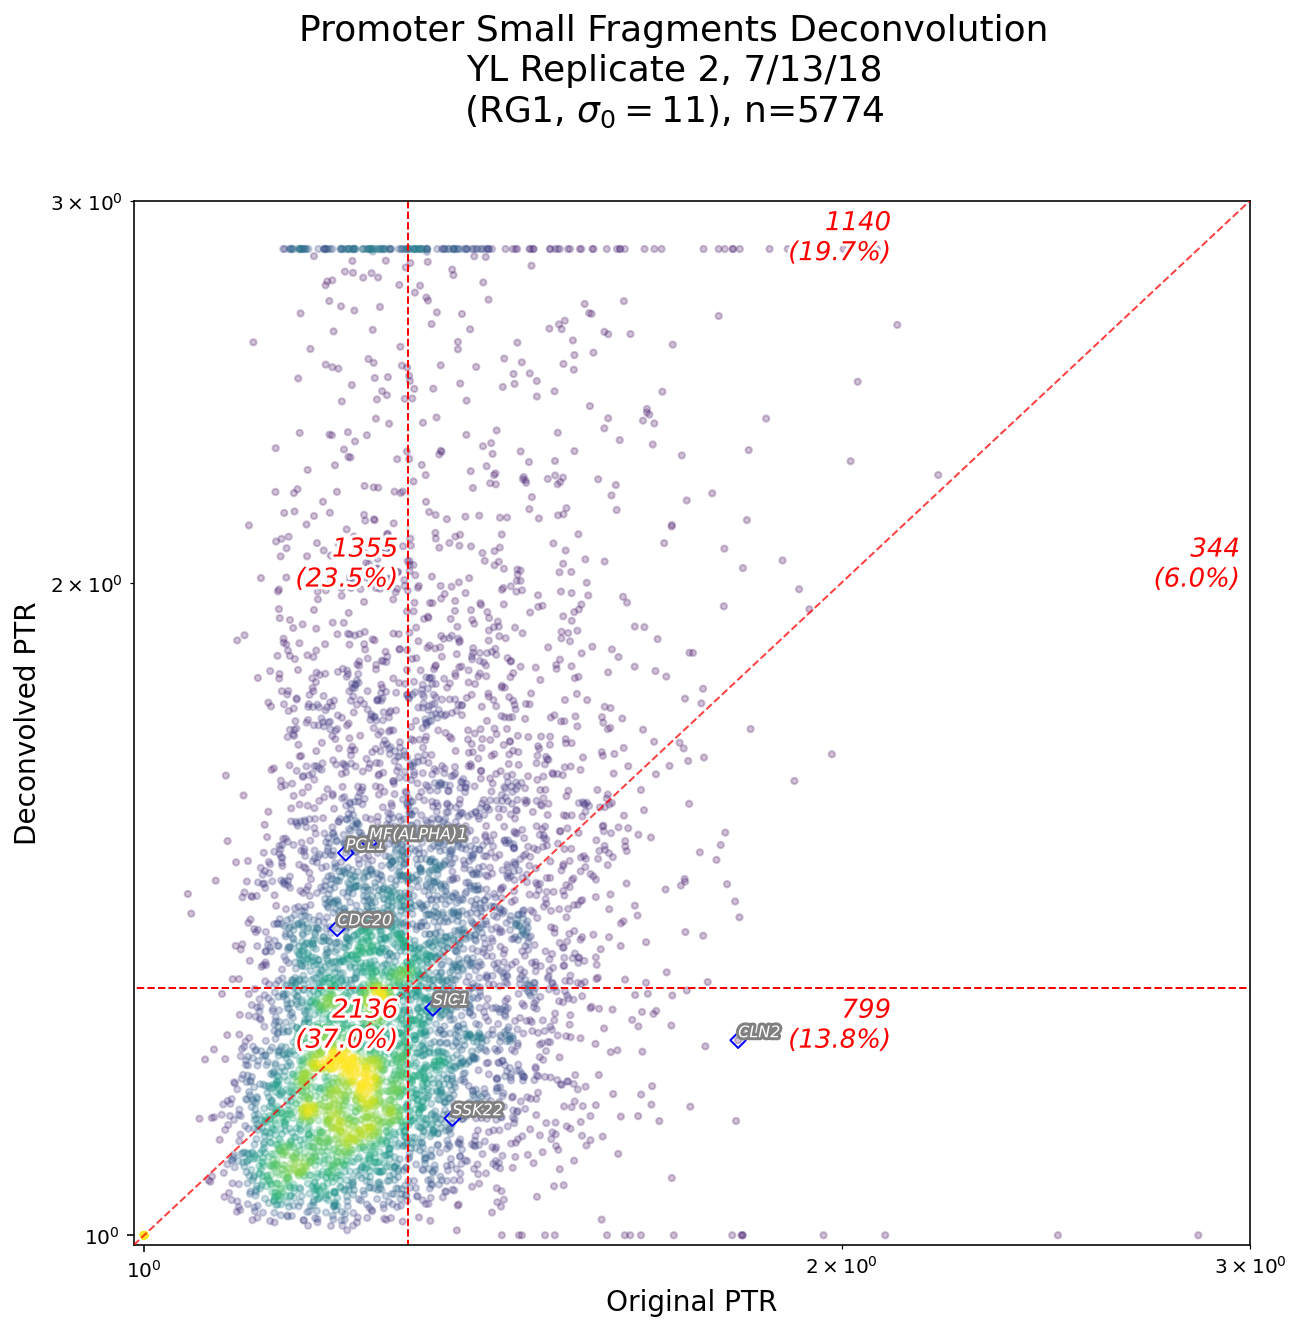

In [23]:
from src.deconvolution_model import plotting_gene_set
from src.load_deconvolutions import load_yl_rep2_small_fragment_occupancy_deconvolution

sm_model, sm_prom_ptrs = load_yl_rep2_small_fragment_occupancy_deconvolution()
model.plot_ptrs_chromatin(plotting_gene_set(), 
                          "Promoter Small Fragments Deconvolution\nYL Replicate 2, 7/13/18\n"
                          "(RG1, $\sigma_0=11$)")
plt.savefig('output/chromatin_gene_expression_ptr_comparison_plots_2023-10-10/sm_prom_ptr.png', dpi=300)

In [24]:
from src.load_deconvolutions import load_yl_rep2_gene_expression_deconvolution
model_ge, ge_ptrs = load_yl_rep2_gene_expression_deconvolution()


In [25]:
plotting_ptrs = sm_prom_ptrs[['combined_ptr']].join(ge_ptrs[['combined_ptr']], lsuffix='_small_prom', rsuffix='_gene_expression')
plotting_ptrs.head(2)

,combined_ptr_small_prom,combined_ptr_gene_expression
YAL001C,1.049902,2.136302
YAL002W,1.333374,1.261937


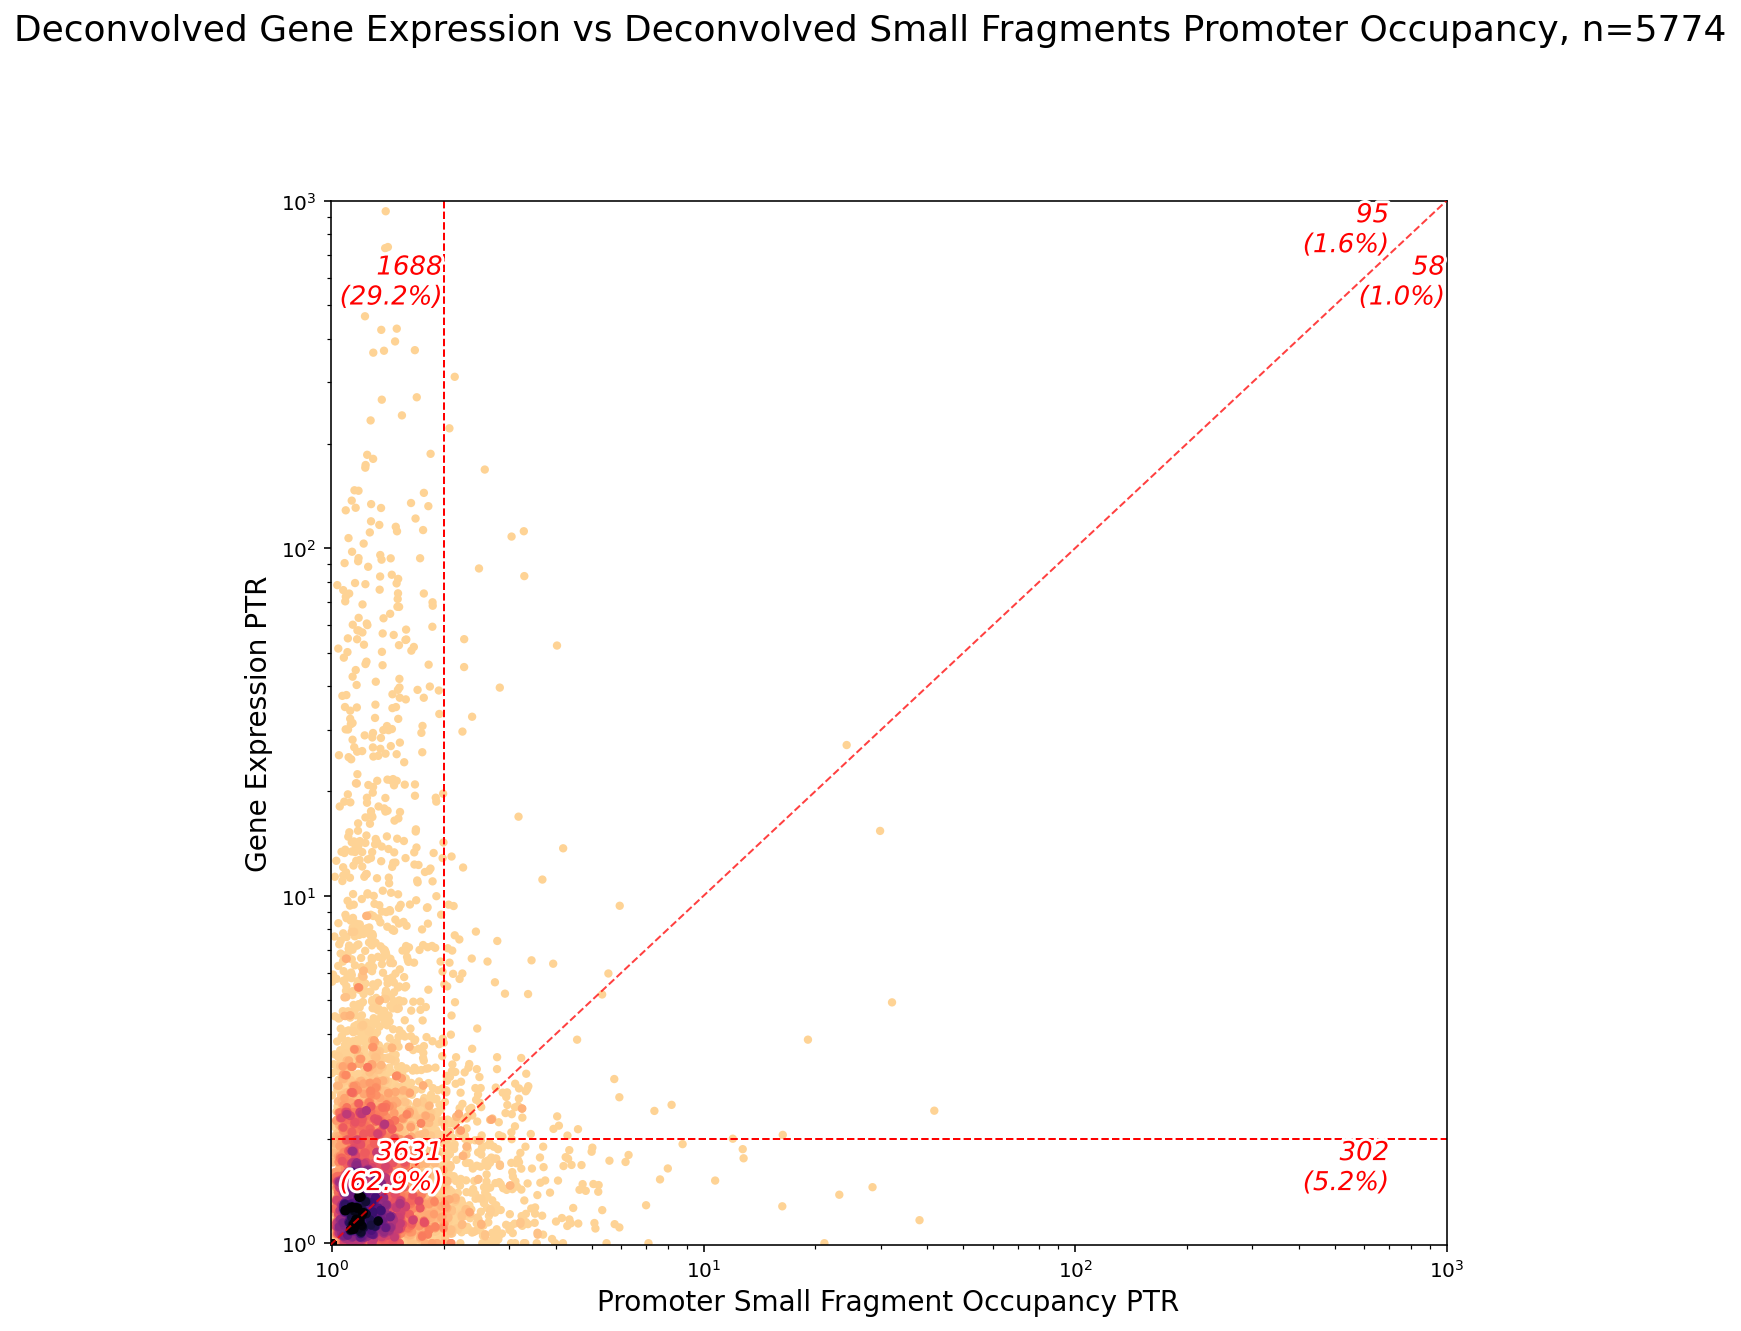

In [26]:
from src.DensityPTRPlotter import DensityPTRPlotter

compare_plotter = DensityPTRPlotter(plotting_ptrs['combined_ptr_small_prom'], 
                                    plotting_ptrs['combined_ptr_gene_expression'],
                                    "Promoter Small Fragment Occupancy PTR", 
                                    "Gene Expression PTR", 1000, 1000, 
                                    "Deconvolved Gene Expression vs Deconvolved Small Fragments Promoter Occupancy")
compare_plotter.plot()
plt.savefig('output/chromatin_gene_expression_ptr_comparison_plots_2023-10-10/sm_prom_vs_ge_ptr.png', dpi=300)

In [27]:
from src.sgd import read_sgd_genes

# Interested in what those genes are in the top right and the bottom right. Start with top right.


segmented_ptrs = plotting_ptrs.copy()
segmented_ptrs = segmented_ptrs.join(read_sgd_genes()[['gene']])

In [28]:
prom_sm_ptr_cutoff = 10
ge_ptr_cutoff = 10
segmented_ptrs[(plotting_ptrs['combined_ptr_small_prom'] > prom_sm_ptr_cutoff) & 
              (segmented_ptrs['combined_ptr_gene_expression'] > ge_ptr_cutoff)]


,combined_ptr_small_prom,combined_ptr_gene_expression,gene
YDL039C,24.263544,27.136019,PRM7
YLL022C,29.849946,15.360580,HIF1
